# E1 · 從零實作貝葉斯最優化(二):維度詛咒、核函數、真實應用

接續 `01_gp_and_acquisition.ipynb`。這本處理:

1. **通關標準 3**:維度詛咒 —— 量出「BO 不再勝過隨機搜尋」的臨界維度
2. **它的機制** —— 並且推翻我自己原本的假設
3. **通關標準 4**:換核函數改變結果 ——「核函數就是先驗」
4. **真實應用**:混凝土配方最優化,計算省下多少次實驗

In [1]:
import sys, os, json, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd
from IPython.display import Image, display
FIG = os.path.abspath('../figures')
RES = json.load(open(os.path.join(FIG, 'results.json')))
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
cfg = RES['config']
print(f"results.json from a {RES['_meta']['runtime_sec']:.0f}s run")
print(f"config: {cfg['n_seeds_main']} seeds (main) / {cfg['n_seeds_dims']} seeds (dimension sweep), "
      f"budget = {cfg['n_total']} evaluations, n_init = {cfg['n_init']}")


results.json from a 1430s run
config: 30 seeds (main) / 20 seeds (dimension sweep), budget = 30 evaluations, n_init = 5


## 1. 通關標準 3:維度詛咒與臨界維度

設計上兩個刻意的選擇:

- **固定評估預算**(50 次),不隨維度放大。因為那才對應真實情境:
  「我只有 50 次實驗機會,維度高低不會改變這件事」。
  後果是高維時 `n_init=10 < d`,GP 幾乎沒有資訊 —— 這正是要展示的。
- **配對比較**:同一個 seed 下比較 BO 與隨機搜尋的最終值。
  配對能抵消初始設計造成的共同噪聲,比各自算平均再相減靈敏得多。

臨界維度的判準:配對優勢的 95% 區間首次涵蓋 0。

In [2]:
dc = RES['dimension_curse']
rows = []
for d in dc['dims']:
    e = dc['per_dim'][str(d)]
    ci = 1.96*e['paired_gain_se']
    rows.append({'維度': f"{d}D",
                 'BO 最終值': e['bo']['final_mean'], 'BO ±sd': e['bo']['final_sd'],
                 '隨機 最終值': e['random']['final_mean'], '隨機 ±sd': e['random']['final_sd'],
                 '配對優勢': e['paired_gain_mean'], '95% CI 半寬': ci,
                 '顯著?': '是' if e['paired_gain_mean']-ci > 0 else '否',
                 'BO 勝率': e['bo_wins_frac']})
display(pd.DataFrame(rows).round(4))
print(f"\n臨界維度（配對優勢的 95% 區間首次涵蓋 0）= {dc['critical_dim']}")
print(f"（預算 {dc['n_total']} 次評估、n_init={dc['n_init']}、refit_every={dc['refit_every']}）")

,維度,BO 最終值,BO ±sd,隨機 最終值,隨機 ±sd,配對優勢,95% CI 半寬,顯著?,BO 勝率
0,2D,1.4783,0.7432,10.3103,3.2868,8.8319,1.5797,是,1.00
1,5D,3.9185,0.9421,17.5774,1.9798,13.6589,1.0148,是,1.00
2,10D,8.6416,3.8424,19.4845,0.8315,10.8428,1.6425,是,1.00
3,20D,16.1735,4.9726,20.4406,0.2910,4.2672,2.1818,是,0.95
4,50D,19.0488,4.3721,20.8167,0.1198,1.7678,1.9191,否,0.75



臨界維度（配對優勢的 95% 區間首次涵蓋 0）= 50
（預算 50 次評估、n_init=10、refit_every=2）


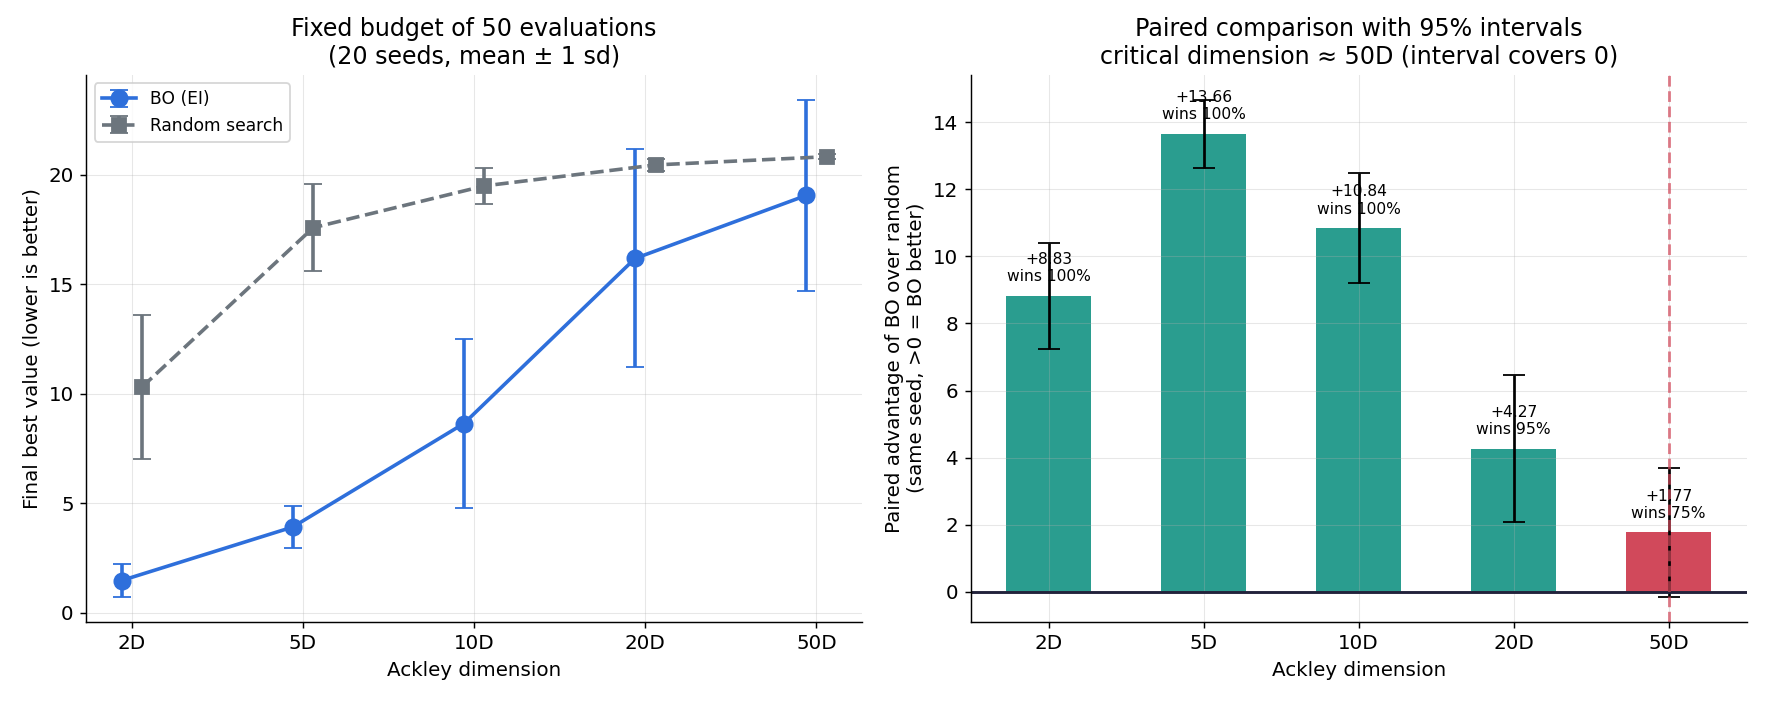

In [3]:
display(Image(os.path.join(FIG, '04_dimension_curse.png')))

## 2. 機制:為什麼高維會失敗?

找出臨界維度只是現象。**機制**才有解釋力,而且它決定「該怎麼補救」。

我原本的假設是:高維下 BO 的失敗來自**內層優化**——
「找 acquisition 的最大值」本身是非凸全域優化,維度一高就解不動了。
如果是這樣,補救方式是加大內層預算(更多候選點、更多重啟)。

所以我做了兩個診斷:

**診斷一 · 核值集中。** 在 $[0,1]^d$ 均勻抽點,看 pairwise 距離與核值的分佈。
高維時距離集中(相對標準差 → 0)且一律變大 → 核值一起趨近 0 →
**每個觀測點都「看不到」其他點**,GP 後驗退化成先驗。

**診斷二 · 內層優化的落差。** 用不同的候選點預算(50 到 20000)解同一個
acquisition 問題,看小預算落後多少。

In [4]:
kc = RES['kernel_concentration']
rows = [{'維度': f"{r['dim']}D", '平均距離': r['dist_mean'],
         '距離相對 sd': r['dist_rel_sd'], '核值中位數': r['kernel_median'],
         '有效鄰居比例 (k>0.1)': r['frac_above_0.1'],
         'k>0.01 比例': r['frac_above_0.01']} for r in kc['rows']]
print(f"診斷一 · 核值集中（{kc['kernel']}, ℓ={kc['lengthscale']}, {kc['n_points']} 個均勻點）")
display(pd.DataFrame(rows))
print('「有效鄰居比例」= 核值 > 0.1 的點對比例。它趨近 0 表示每個點都孤立。')

診斷一 · 核值集中（Matern52, ℓ=0.3, 200 個均勻點）


,維度,平均距離,距離相對 sd,核值中位數,有效鄰居比例 (k>0.1),k>0.01 比例
0,2D,0.533152,0.476145,2.015281e-01,0.686080,0.986131
1,5D,0.865976,0.283554,3.315657e-02,0.212714,0.802161
2,10D,1.276257,0.195619,2.933578e-03,0.007186,0.212814
3,20D,1.805423,0.135971,1.038950e-04,0.000000,0.002111
4,50D,2.878308,0.084617,8.412592e-08,0.000000,0.000000


「有效鄰居比例」= 核值 > 0.1 的點對比例。它趨近 0 表示每個點都孤立。


In [5]:
sf = RES['acq_shortfall']
rows = []
for e in sf['per_dim']:
    rows.append({'維度': f"{e['dim']}D",
                 '學到的 ℓ': e['gp_lengthscale_mean'],
                 '後驗均值動態範圍 ÷ y 範圍': e['mu_spread_over_yrange_mean'],
                 'best EI ÷ y 範圍': e['best_ei_over_yrange_mean'],
                 '內層優化落差': e['shortfall_at_smallest_mean'],
                 'seeds': e['n_seeds']})
print(f"診斷二 · 內層優化 vs 模型退化（{sf['n_obs']} 個觀測點，{sf['per_dim'][0]['n_seeds']} seeds 平均）")
display(pd.DataFrame(rows).round(6))

診斷二 · 內層優化 vs 模型退化（30 個觀測點，8 seeds 平均）


,維度,學到的 ℓ,後驗均值動態範圍 ÷ y 範圍,best EI ÷ y 範圍,內層優化落差,seeds
0,2D,0.204557,1.007903,0.053802,0.000000,8
1,5D,0.223027,0.684982,0.005124,-0.000000,8
2,10D,0.309457,0.314564,0.002290,0.003604,8
3,20D,0.460673,0.178146,0.003686,0.000000,8
4,50D,0.351057,0.015760,0.000660,0.000001,8


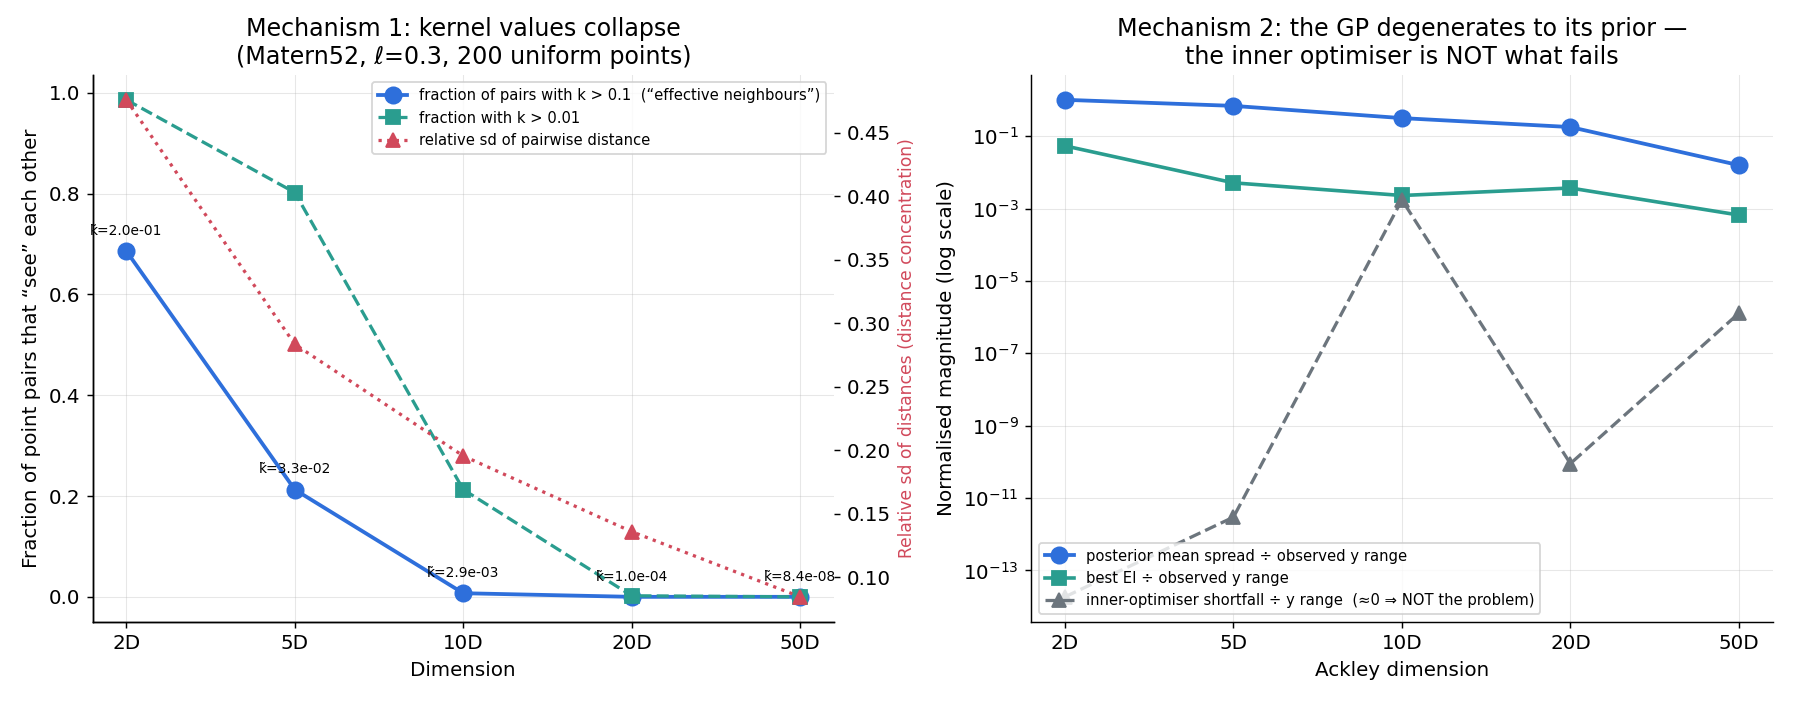

In [6]:
display(Image(os.path.join(FIG, '05_curse_mechanism.png')))

### 我的假設被推翻了

**「內層優化落差」幾乎全是 0** —— 用 50 個候選點找到的 acquisition 值
與用 20000 個幾乎相同。內層優化**沒有**失敗。

真正發生的是更根本的事:高維下 GP 退化成先驗,
**acquisition 變平坦,根本沒有最大值可找**。任何預算都會找到同一個平坦值。

證據在另外兩個量(都已除以實際觀測到的 y 範圍,排除「Ackley 高維值域本身縮小」的混淆):

- **後驗均值動態範圍 ÷ y 範圍**:從 2D 的接近 1 崩到 50D 的百分之幾。
  也就是說,GP 的後驗均值在高維幾乎是**常數** —— 它對這批資料什麼都沒學到。
- **best EI ÷ y 範圍**:同樣崩掉數個數量級。EI 的最大值是「最值得試的那一點
  期望能改善多少」,它趨近 0 就表示模型認為**到處都不值得試**。

> **補救方式完全不同。** 如果是內層優化的問題,加大候選點預算就好;
> 但既然是 GP 退化,那要換的是**模型**(降維、加性核、trust region、
> 或改用隨機搜尋認賠)。這就是為什麼機制診斷不能省 ——
> 它決定了你下一步該做什麼。

正規化這件事本身也是必要的誠實:Ackley 的函數值範圍隨維度縮小
(餘弦項被平均掉),不除以 y 範圍的話,絕對值的下降會有一部分只是尺度效應。

## 3. 通關標準 4:核函數就是先驗

| 核函數 | 平滑度假設 |
|---|---|
| **RBF** | $\exp(-r^2/2\ell^2)$,**無限可微** |
| **Matérn 5/2** | $(1+\sqrt5 r/\ell + 5r^2/3\ell^2)e^{-\sqrt5 r/\ell}$,**兩次可微** |

RBF 假設目標函數無限平滑,會把觀測之間的行為推斷得過度平滑;
在崎嶇的目標(如 Ackley)上它必須用很短的 lengthscale 才能擬合,
而那讓後驗在觀測點之間迅速回到先驗。Matérn 5/2 只要求兩次可微,
能用較長的 lengthscale 描述同樣的資料。

**這個差異是可以量出來的**,不只是理論說法 —— 下表的 lengthscale 欄。

In [7]:
kcp = RES['kernel_comparison']
rows = []
for oname, e in kcp['per_objective'].items():
    for kn, a in e['kernels'].items():
        rows.append({'目標函數': f"{oname} ({e['dim']}D)", '核函數': kn,
                     '最終最佳值': a['final_mean'], '± sd': a['final_sd'],
                     '學到的 ℓ': a['final_lengthscale_mean'],
                     'ℓ 的 sd': a['final_lengthscale_sd'],
                     '學到的 noise': a['final_noise_mean']})
display(pd.DataFrame(rows).round(4))
print()
for oname, e in kcp['per_objective'].items():
    ci = 1.96*e['paired_diff_se']
    sig = '顯著' if abs(e['paired_diff_mean']) > ci else '不顯著'
    print(f"  {oname:10s} 配對差異 {e['paired_diff_mean']:+.4f} ± {ci:.4f} → "
          f"較佳: {e['better']} ({sig})")

,目標函數,核函數,最終最佳值,± sd,學到的 ℓ,ℓ 的 sd,學到的 noise
0,Branin (2D),RBF,0.5470,0.2150,0.3216,0.1040,0.0114
1,Branin (2D),Matern52,0.4474,0.0770,0.7448,0.1689,0.0067
2,Ackley5D (5D),RBF,6.4900,3.8113,0.1445,0.0425,0.2074
3,Ackley5D (5D),Matern52,6.4501,3.9102,0.2011,0.0525,0.1281



  Branin     配對差異 +0.0996 ± 0.0713 → 較佳: Matern52 (顯著)
  Ackley5D   配對差異 +0.0399 ± 1.8896 → 較佳: Matern52 (不顯著)


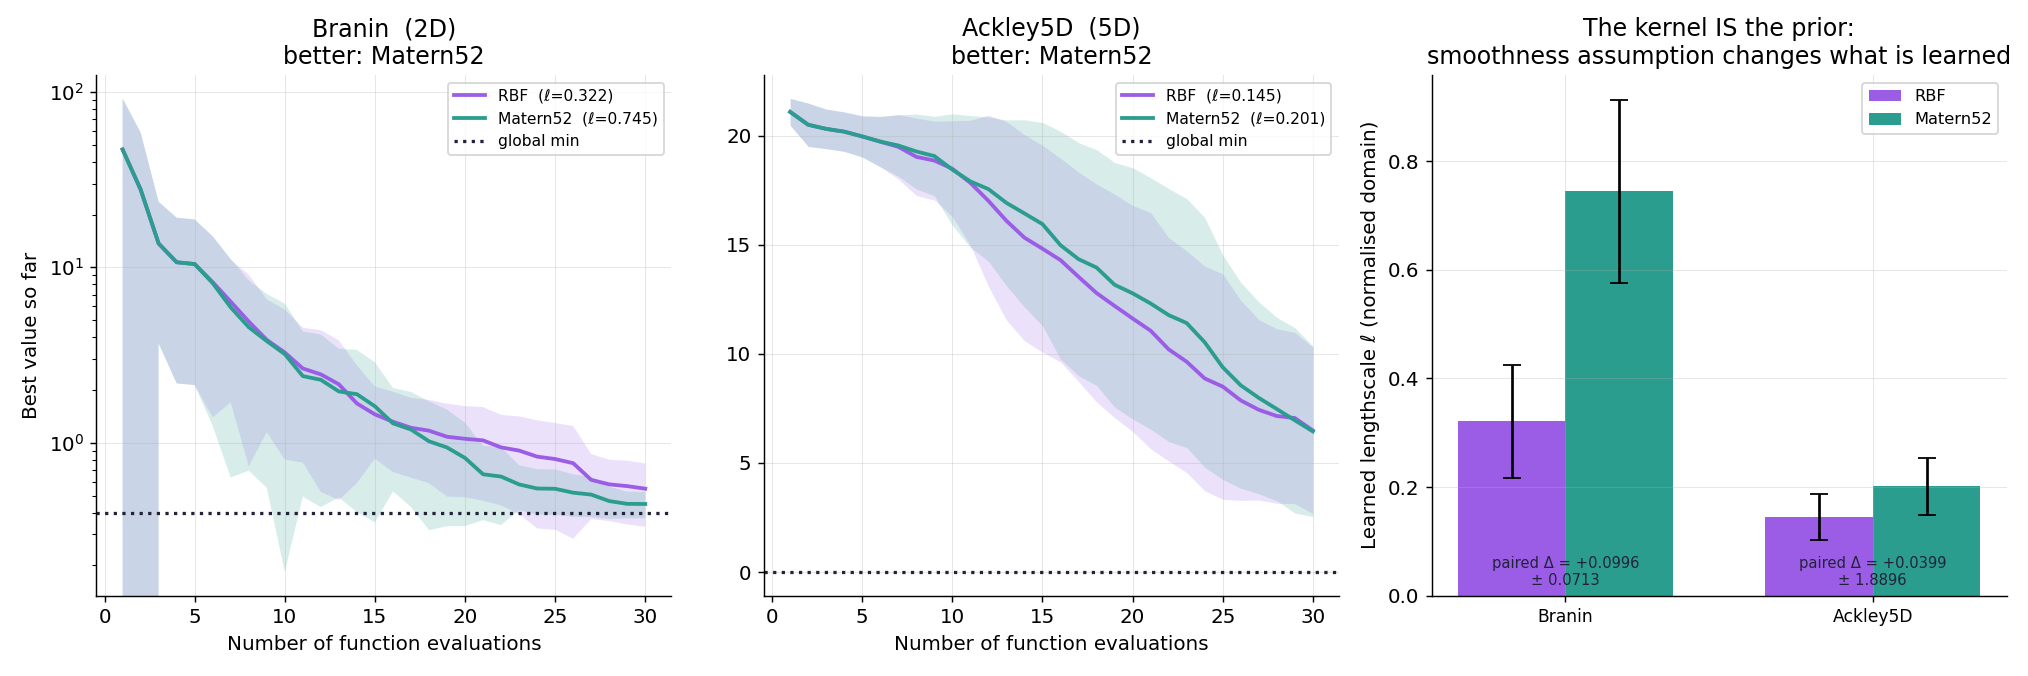

In [8]:
display(Image(os.path.join(FIG, '06_kernel_comparison.png')))

## 4. 真實應用:混凝土配方最優化

E-D2(UCI Concrete Compressive Strength,1030 筆、8 個配方變數 → 抗壓強度)。

做法:用梯度提升迴歸在全部資料上訓練一個代理模型,當作「做一次實驗
就能得到的真實強度」。BO 的任務是用最少的查詢次數找到強度最高的配方。

**「省下多少次實驗」的定義**:隨機搜尋用完全部預算達到某個強度水準,
BO 需要幾次就能達到同樣水準?差額就是省下的次數。

In [9]:
ca = RES['concrete']
s = ca['surrogate']
print(f"代理模型: HistGradientBoosting, 5-fold CV R² = {s['surrogate_cv_r2_mean']:.4f} ± {s['surrogate_cv_r2_std']:.4f}")
print(f"  資料中最高強度 = {s['best_in_data']:.2f} MPa, 平均 = {s['mean_in_data']:.2f} MPa")
print(f"  搜尋範圍取各變數的 [1%, 99%] 分位數（避免代理模型在稀疏角落外插出假高值）")
print()
print(f"預算 {ca['n_total']} 次實驗、{ca['bo']['n_seeds']} seeds:")
print(f"  BO (EI)   最終強度 {ca['bo_strength_mean']:.2f} ± {ca['bo_strength_sd']:.2f} MPa")
print(f"  隨機搜尋   最終強度 {ca['random_strength_mean']:.2f} ± {ca['random_strength_sd']:.2f} MPa")
print(f"  配對優勢   {ca['paired_gain_mean_mpa']:+.2f} ± {1.96*ca['paired_gain_se_mpa']:.2f} MPa"
      f"  (BO 勝率 {100*ca['bo_wins_frac']:.0f}%)")
print()
print(f"  BO 只用 {ca['evals_bo_to_match_random_final']} 次就達到隨機搜尋花光 {ca['n_total']} 次的水準")
print(f"  → 省下 {ca['evals_saved']} 次實驗 ({ca['saved_pct']:.0f}%)")
print()
print(f"找到的最佳配方（{ca['best_strength_found']:.2f} MPa）:")
for k, v in ca['best_recipe'].items():
    print(f"    {k:12s} {v:8.2f}")

代理模型: HistGradientBoosting, 5-fold CV R² = 0.9352 ± 0.0109
  資料中最高強度 = 82.60 MPa, 平均 = 35.82 MPa
  搜尋範圍取各變數的 [1%, 99%] 分位數（避免代理模型在稀疏角落外插出假高值）

預算 40 次實驗、30 seeds:
  BO (EI)   最終強度 79.25 ± 2.17 MPa
  隨機搜尋   最終強度 75.28 ± 2.42 MPa
  配對優勢   +3.96 ± 1.16 MPa  (BO 勝率 90%)

  BO 只用 14 次就達到隨機搜尋花光 40 次的水準
  → 省下 26 次實驗 (65%)

找到的最佳配方（84.17 MPa）:
    Cement         406.17
    Slag           290.20
    FlyAsh           0.00
    Water          167.60
    Superplast      11.26
    CoarseAgg      823.44
    FineAgg        755.10
    Age             92.96


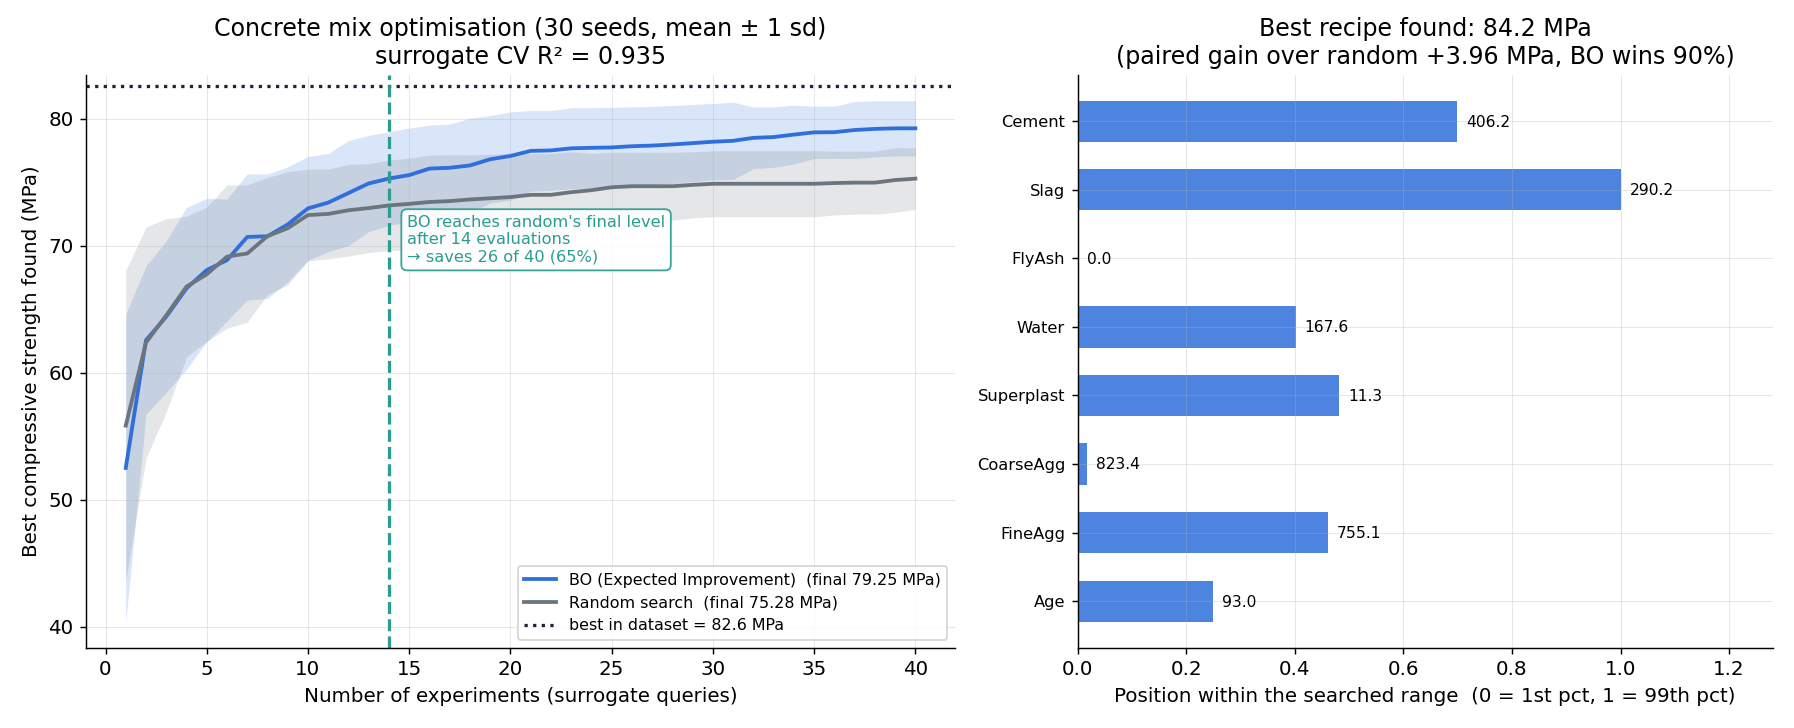

In [10]:
display(Image(os.path.join(FIG, '07_concrete.png')))

### 這個數字的誠實面

代理模型**不是**真實世界。它平滑掉了真實製程的噪聲與不可行區域,
所以「省下 N 次實驗」是在這個代理上的數字。但它保留了真實資料的維度、
變數尺度與交互作用結構,比在解析測試函數上宣稱「材料應用」誠實得多。

另外要注意 BO 找到的配方是否落在搜尋範圍的**邊界**上(右圖的長條)。
若某個成分頂在 99% 分位數,那表示真正的最優可能在範圍之外,
而代理模型在那裡是外插 —— 不該相信。

## 小結與誠實面

| 通關標準 | 結果 |
|---|---|
| 1 · 低維時 BO 明顯勝過隨機搜尋 | 見第一本 |
| 2 · κ=0 卡局部最優的軌跡清晰可見 | 見第一本 |
| 3 · 高維時兩者收斂接近,量出臨界維度 | 見第 1 節 |
| 4 · 換核函數改變結果 | 見第 3 節 |

**方法論上最有價值的部分是第 2 節推翻了自己的假設**:
我原以為高維 BO 的失敗來自內層優化解不動,實測顯示內層優化沒問題,
真正的問題是 GP 退化成先驗、acquisition 平坦化。
這兩者的補救方式完全不同,所以區分它們有實際價值。

完整限制與誠實章節見 [`../README.md`](../README.md)。